# Basic Properties of Returns
The most fundamental analysis of a stock, portfolio, or other asset might be to track its value over time, also known as the returns of an asset. This section of the documentation will review the basic properties of these returns, such as the methods for computing returns and the statistical analysis of returns. First it is useful to review the basic equation for computing the value of an asset over time:

$$
S(t) = S(t-1) + S(t-1)R(t) = S(t-1) \begin{pmatrix}1 + R(t)\end{pmatrix}
$$

where $S(t)$ is the asset value at time $t$, $R(t)$ is the "simple" rate of returns, and \begin{pmatrix}1 + R(t)\end{pmatrix} is the simple gross returns. 

```{note}
The gross returns and rate of returns describe the same exact concept. The only difference is that gross return describes the total value of the asset whereas the rate of returns only describes the value of the return. I.E., the gross returns for an asset that has changed from $100 to $150 would be 150% while the rate of returns is 50%.
```

The above equation can be easily arranged to compute the simple rate of returns, which is simply the percent change in the value of the asset:

$$
R(t) = \frac{S(t)}{S(t-1)} - 1 = \frac{S(t)-S(t-1)}{S(t-1)}
$$ 

## Compounding Returns
The simple returns on an asset value compound over time, since the percentage change at present A simple example can be used to demonstrate how the returns compound over time. First, the asset value is computed for $t-1$:

$$
S(t-1) = S(t-2) \begin{pmatrix}1 + R(t-1)\end{pmatrix}
$$

this equation is then inserted into the first equation above to compute the asset value at time $t$, starting at time $t-2$:

$$
S(t) =  S(t-2) \begin{pmatrix}1 + R(t-1)\end{pmatrix} \begin{pmatrix}1 + R(t)\end{pmatrix}
$$

Given the compounding of the returns, the asset value can also be computed with the exponential function:

$$
S(t) = S(t-1) e^{r(t)}
$$

where $r(t)$ is the "log-returns" that are computed with the natural log of gross returns:

$$
r(t) = ln\begin{pmatrix}1+R(t)\end{pmatrix}
$$

Using the exponential function and log-returns to model the asset value has two significant benefits:

1. The returns from the exponential function are continuous in time
2. The log-returns are additive in time rather than multiplicative, since the compounded log-return is:

$$
ln\begin{pmatrix}\begin{pmatrix}1 + R(t)\end{pmatrix} \begin{pmatrix}1 + R(t-1)\end{pmatrix} + ...\end{pmatrix} = ln\begin{pmatrix}1 + R(t)\end{pmatrix} + ln\begin{pmatrix}1 + R(t-1)\end{pmatrix} + ... = r(t) + r(t-1) + ...
$$

## Evaluating Returns of Historical Stock Data


In [86]:
import numpy as np
from scipy.stats import skew, kurtosis, probplot, norm, lognorm
import yfinance as yf
import datetime as dt
import matplotlib.pyplot as plt

In [ ]:
start_date = dt.datetime(2025,1,1)
end_date = dt.datetime(2026,5,1)

stock_data = yf.download(['NVDA'], start=start_date, end=end_date)
simple_returns = stock_data['Close'].pct_change().to_numpy()[1:,0]
gross_returns = 1 + simple_returns
log_returns = np.log(gross_returns)

[*********************100%***********************]  1 of 1 completed


In [127]:
print('Average return: {:}'.format(np.mean(simple_returns)))
print('Return variance: {:}'.format(np.var(simple_returns)))
print('Return skewness: {:}'.format(skew(simple_returns)))
print('Return kurtosis: {:}'.format(kurtosis(simple_returns)))

Average return: 0.001541615595275462
Return variance: 0.0008614050705322269
Return skewness: -0.038858417663091394
Return kurtosis: 7.7519154664443235


In [128]:
simple_return_pdf_abscissa = np.linspace(simple_returns.min(), simple_returns.max(), 100)
simple_return_pdf_ordinate = norm.pdf(simple_return_pdf_abscissa, 
                                     loc=np.mean(simple_returns), 
                                     scale=np.std(simple_returns))

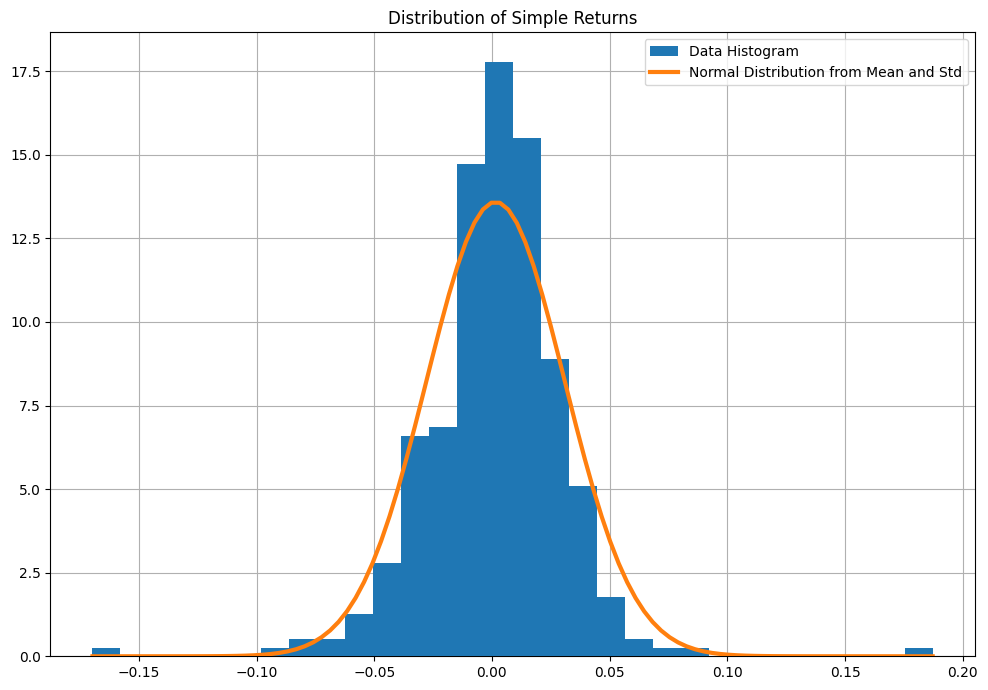

In [129]:
plt.figure(figsize=(10,7))
plt.hist(simple_returns, bins=30, label='Data Histogram', zorder=3, density=True);
plt.plot(simple_return_pdf_abscissa, simple_return_pdf_ordinate, linewidth=3, 
         label='Normal Distribution from Mean and Std', zorder=4)
plt.legend(); plt.grid(zorder=0); plt.title('Distribution of Simple Returns');
plt.tight_layout()

In [115]:
print('Average return: {:}'.format(np.mean(log_returns)))
print('Return variance: {:}'.format(np.var(log_returns)))
print('Return skewness: {:}'.format(skew(log_returns)))
print('Return kurtosis: {:}'.format(kurtosis(log_returns)))

Average return: 0.0011087463936708198
Return variance: 0.0008668130942072663
Return skewness: -0.462409584920027
Return kurtosis: 7.79173594714004


In [116]:
log_return_pdf_abscissa = np.linspace(log_returns.min(), log_returns.max(), 100)
log_return_pdf_ordinate = norm.pdf(log_return_pdf_abscissa, loc=np.mean(log_returns), scale=np.std(log_returns))

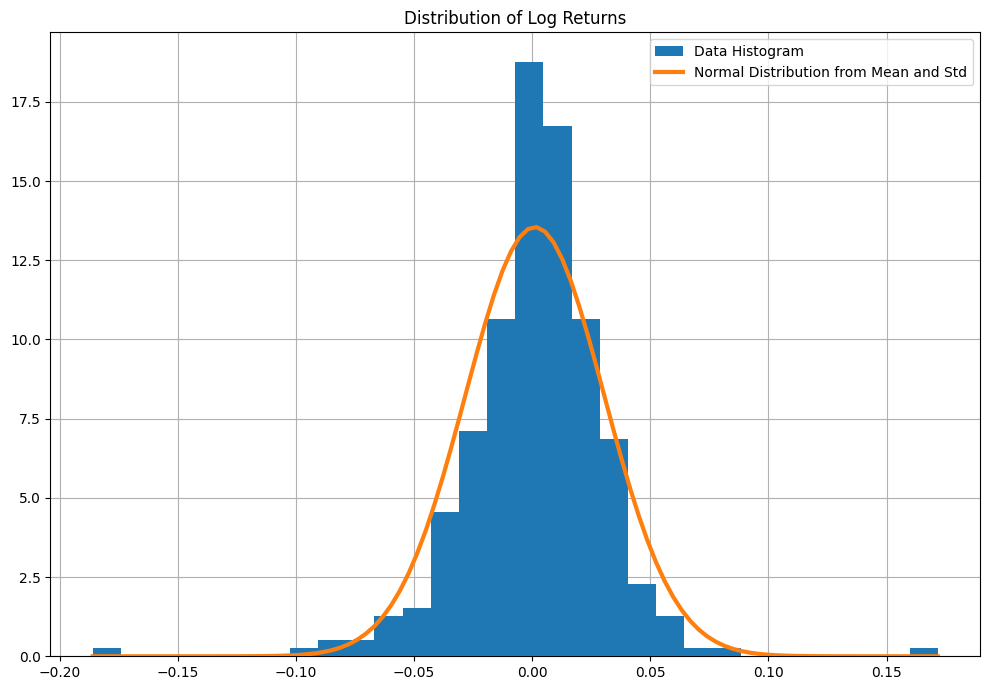

In [117]:
plt.figure(figsize=(10,7))
plt.hist(log_returns, bins=30, #int(simple_returns.shape[0]/4), 
         label='Data Histogram', zorder=3, density=True);
plt.plot(log_return_pdf_abscissa, log_return_pdf_ordinate, linewidth=3, 
         label='Normal Distribution from Mean and Std', zorder=4)
plt.legend(); plt.grid(zorder=0); plt.title('Distribution of Log Returns');
plt.tight_layout()

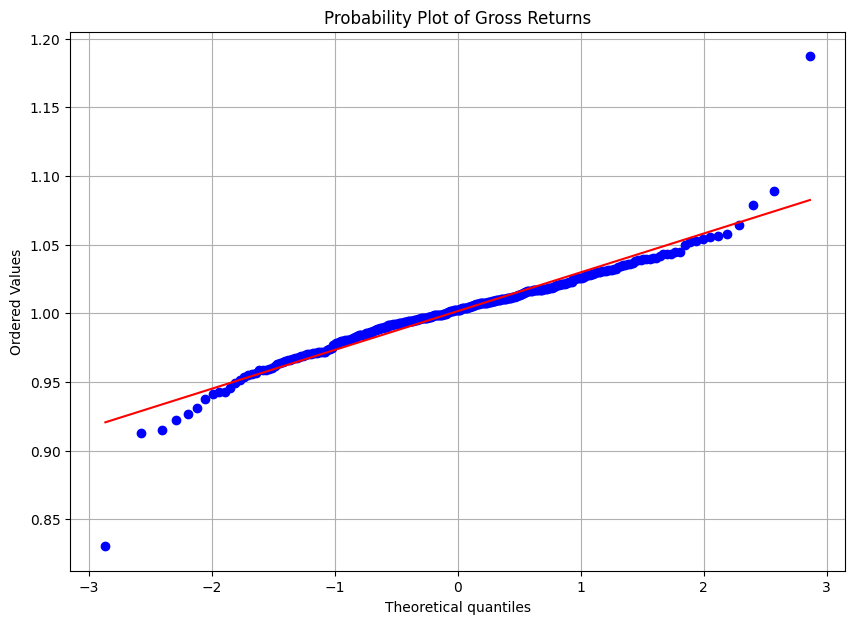

In [118]:
fig, ax = plt.subplots(figsize=(10,7))
res = probplot(gross_returns, plot=ax)
ax.set_title('Probability Plot of Gross Returns'); ax.grid()

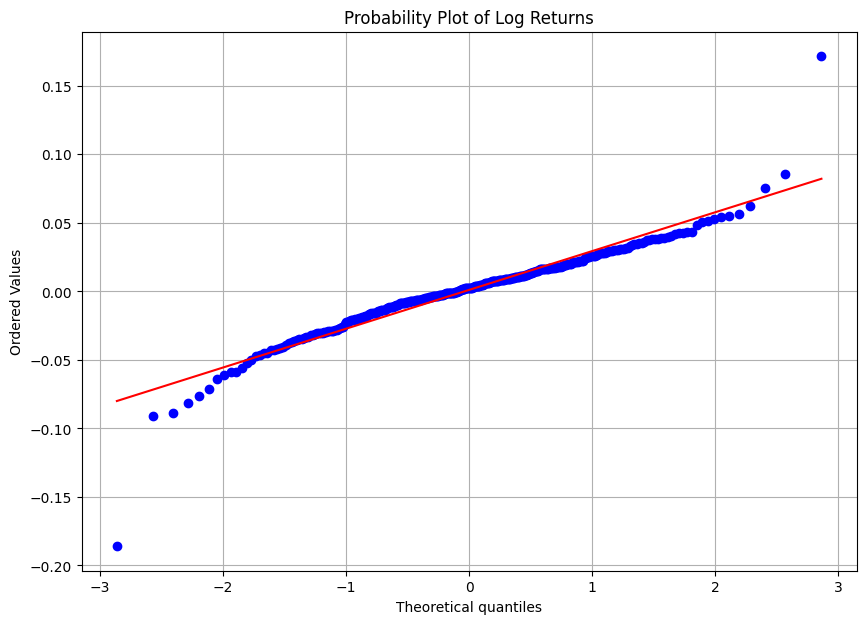

In [119]:
fig, ax = plt.subplots(figsize=(10,7))
res = probplot(log_returns, plot=ax)
ax.set_title('Probability Plot of Log Returns'); ax.grid()